# Phase 8-A — Expanded Real and GRMHD Validation

This notebook expands the external-validation layer after Phase 7.

It does **not** attempt real black-hole history recovery. Instead, it asks whether the Phase 7 conclusion remains stable when the external observational set is expanded with additional EHT-like real images and/or GRMHD-rendered images.

Run this notebook after completing:

- Phase 7-A — Real Observation Consistency Study
- Phase 7-B — Synthetic-to-Real Latent Calibration
- Phase 7-C — Calibration Robustness
- Phase 7-D — Calibrated Synthetic Analogue Memory Mapping
- Phase 7-D.1 — Metadata Recovery and Event-Family Reconstruction

Expected external folders:

```text
data/real_observations/eht/m87/
data/real_observations/eht/sgrA/
data/real_observations/eht/misc/
data/grmhd_simulations/phase7A2_grmhd_harvest/
data/grmhd_simulations/external_grmhd_images/
data/grmhd_simulations/raw_grmhd/
```

Main outputs are saved to:

```text
outputs/phase8A_expanded_real_grmhd_validation/
```


In [1]:
# ================================================================
# 1. Imports and global configuration
# ================================================================

import os
import re
import json
import math
import shutil
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

try:
    from PIL import Image, ImageOps
    PIL_AVAILABLE = True
except Exception:
    PIL_AVAILABLE = False

try:
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    from sklearn.neighbors import NearestNeighbors
    from sklearn.metrics import pairwise_distances
    SKLEARN_AVAILABLE = True
except Exception as e:
    SKLEARN_AVAILABLE = False
    print('scikit-learn unavailable:', e)

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path('/home/marwa/files/phase1_blackhole_generator')
DATA_ROOT = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'

PHASE7A_DIR = OUTPUT_DIR / 'phase7A_real_observation_consistency'
PHASE7B_DIR = OUTPUT_DIR / 'phase7B_synthetic_to_real_calibration'
PHASE7C_DIR = OUTPUT_DIR / 'phase7C_calibration_robustness'
PHASE7D_DIR = OUTPUT_DIR / 'phase7D_calibrated_memory_mapping'
PHASE7D1_DIR = OUTPUT_DIR / 'phase7D1_metadata_recovery_event_family_reconstruction'

PHASE7A_TABLE_DIR = PHASE7A_DIR / 'tables'
PHASE7B_TABLE_DIR = PHASE7B_DIR / 'tables'
PHASE7C_TABLE_DIR = PHASE7C_DIR / 'tables'
PHASE7D_TABLE_DIR = PHASE7D_DIR / 'tables'
PHASE7D1_TABLE_DIR = PHASE7D1_DIR / 'tables'

REAL_OBS_DIR = DATA_ROOT / 'real_observations'
EHT_DIR = REAL_OBS_DIR / 'eht'
M87_DIR = EHT_DIR / 'm87'
SGRA_DIR = EHT_DIR / 'sgrA'
MISC_REAL_DIR = EHT_DIR / 'misc'

GRMHD_DIR = DATA_ROOT / 'grmhd_simulations'
GRMHD_HARVEST_DIR = GRMHD_DIR / 'phase7A2_grmhd_harvest'
EXTERNAL_GRMHD_DIR = GRMHD_DIR / 'external_grmhd_images'
RAW_GRMHD_DIR = GRMHD_DIR / 'raw_grmhd'

PHASE8A_DIR = OUTPUT_DIR / 'phase8A_expanded_real_grmhd_validation'
PHASE8A_TABLE_DIR = PHASE8A_DIR / 'tables'
PHASE8A_FIG_DIR = PHASE8A_DIR / 'figures'
PHASE8A_REPORT_DIR = PHASE8A_DIR / 'reports'
PHASE8A_ASSET_DIR = PHASE8A_DIR / 'copied_key_assets'

for d in [
    M87_DIR, SGRA_DIR, MISC_REAL_DIR,
    GRMHD_HARVEST_DIR, EXTERNAL_GRMHD_DIR, RAW_GRMHD_DIR,
    PHASE8A_DIR, PHASE8A_TABLE_DIR, PHASE8A_FIG_DIR, PHASE8A_REPORT_DIR, PHASE8A_ASSET_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

BRIDGE_DATASET = 'phase7A2_grmhd_harvest'
REFERENCE_DATASETS = [
    'phase1_original',
    'phase5_8_morphology',
    'phase5_coupled',
    'phase6_memory',
    'phase7A2_grmhd_harvest',
]

IMAGE_SIZE = 128
MAX_SYNTHETIC_PER_DATASET = 500
N_NEIGHBORS = 10
TOP_K_ANALOGUES = 10

IMAGE_EXTENSIONS = ['*.png', '*.jpg', '*.jpeg', '*.tif', '*.tiff', '*.bmp', '*.webp']
DATA_EXTENSIONS = ['*.fits', '*.fit', '*.fts', '*.h5', '*.hdf5']

print('Project root:', PROJECT_ROOT)
print('Phase 8-A output:', PHASE8A_DIR)
print('PIL available:', PIL_AVAILABLE)
print('sklearn available:', SKLEARN_AVAILABLE)


/home/marwa/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Project root: /home/marwa/files/phase1_blackhole_generator
Phase 8-A output: /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation
PIL available: True
sklearn available: True


In [2]:
# ================================================================
# 2. Helper functions
# ================================================================

def read_csv_if_exists(path):
    path = Path(path)
    if not path.exists():
        return None
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        print('Empty CSV:', path)
        return pd.DataFrame()
    except Exception as e:
        print(f'Could not read CSV {path}: {e}')
        return None

def read_json_if_exists(path):
    path = Path(path)
    if not path.exists():
        return None
    try:
        with open(path, 'r') as f:
            return json.load(f)
    except Exception as e:
        print(f'Could not read JSON {path}: {e}')
        return None

def save_dataframe(df, name, index=False):
    path = PHASE8A_TABLE_DIR / f'{name}.csv'
    df.to_csv(path, index=index)
    return path

def save_plot(filename):
    path = PHASE8A_FIG_DIR / filename
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches='tight')
    plt.show()
    return path

def df_to_text(df, max_rows=25):
    if df is None or len(df) == 0:
        return 'No data available.'
    return df.head(max_rows).to_string(index=False)

def list_matching_files(folder, patterns, recursive=True):
    folder = Path(folder)
    files = []
    for pat in patterns:
        files.extend(folder.rglob(pat) if recursive else folder.glob(pat))
    return sorted({p for p in files if p.is_file()})

def list_images(folder, recursive=True):
    return list_matching_files(folder, IMAGE_EXTENSIONS, recursive=recursive)

def list_data_products(folder, recursive=True):
    return list_matching_files(folder, DATA_EXTENSIONS, recursive=recursive)

def file_info(path):
    path = Path(path)
    if not path.exists():
        return {'path': str(path), 'exists': False, 'is_file': False, 'size_bytes': np.nan, 'modified_time': ''}
    stat = path.stat()
    return {
        'path': str(path),
        'exists': True,
        'is_file': path.is_file(),
        'size_bytes': int(stat.st_size) if path.is_file() else np.nan,
        'modified_time': datetime.fromtimestamp(stat.st_mtime).isoformat(),
    }

def relative_or_str(path, root=PROJECT_ROOT):
    path = Path(path)
    try:
        return str(path.relative_to(root))
    except Exception:
        return str(path)

def clean_sample_id_from_path(path):
    stem = Path(str(path)).stem
    stem = stem.replace('_noisy', '')
    stem = stem.replace('clean_', '')
    stem = re.sub(r'[^A-Za-z0-9_\-]+', '_', stem)
    return stem

def safe_numeric(x):
    return pd.to_numeric(x, errors='coerce')

def load_image01(path, size=128):
    if not PIL_AVAILABLE:
        raise RuntimeError('PIL is required for image loading.')
    img = Image.open(path).convert('L')
    w, h = img.size
    crop = min(w, h)
    img = ImageOps.fit(img, (crop, crop), method=Image.Resampling.LANCZOS, centering=(0.5, 0.5))
    img = img.resize((size, size), Image.Resampling.LANCZOS)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return np.clip(arr, 0.0, 1.0)

def radial_profile_features(image):
    y, x = np.indices(image.shape)
    cy = (image.shape[0] - 1) / 2.0
    cx = (image.shape[1] - 1) / 2.0
    r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
    r_norm = r / max(r.max(), 1e-8)
    center = image[r_norm <= 0.18]
    inner_ring = image[(r_norm > 0.18) & (r_norm <= 0.38)]
    outer_ring = image[(r_norm > 0.38) & (r_norm <= 0.62)]
    background = image[r_norm > 0.72]
    return center, inner_ring, outer_ring, background, r_norm

def image_morphology(path, size=128):
    img = load_image01(path, size=size)
    center, inner_ring, outer_ring, background, r_norm = radial_profile_features(img)
    h, w = img.shape
    left = img[:, :w//2]
    right = img[:, w//2:]
    top = img[:h//2, :]
    bottom = img[h//2:, :]
    yy, xx = np.indices(img.shape)
    total = img.sum() + 1e-8
    cx = float((xx * img).sum() / total) / max(w - 1, 1)
    cy = float((yy * img).sum() / total) / max(h - 1, 1)
    center_mean = float(np.mean(center)) if len(center) else np.nan
    inner_mean = float(np.mean(inner_ring)) if len(inner_ring) else np.nan
    outer_mean = float(np.mean(outer_ring)) if len(outer_ring) else np.nan
    bg_mean = float(np.mean(background)) if len(background) else np.nan
    bright_threshold = np.quantile(img, 0.92)
    bright_mask = img >= bright_threshold
    bright_fraction = float(np.mean(bright_mask))
    return {
        'mean_intensity': float(np.mean(img)),
        'std_intensity': float(np.std(img)),
        'max_intensity': float(np.max(img)),
        'center_mean': center_mean,
        'inner_ring_mean': inner_mean,
        'outer_ring_mean': outer_mean,
        'background_mean': bg_mean,
        'ring_to_center_ratio': float((max(inner_mean, outer_mean) + 1e-8) / (center_mean + 1e-8)),
        'outer_to_background_ratio': float((outer_mean + 1e-8) / (bg_mean + 1e-8)),
        'left_right_asymmetry': float(abs(np.mean(left) - np.mean(right)) / (np.mean(img) + 1e-8)),
        'top_bottom_asymmetry': float(abs(np.mean(top) - np.mean(bottom)) / (np.mean(img) + 1e-8)),
        'centroid_x': cx,
        'centroid_y': cy,
        'bright_fraction': bright_fraction,
        'texture_proxy': float(np.mean(np.abs(np.diff(img, axis=0))) + np.mean(np.abs(np.diff(img, axis=1)))),
    }

def copy_if_exists(src, dst_dir):
    src = Path(src)
    dst_dir = Path(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)
    if src.exists() and src.is_file():
        dst = dst_dir / src.name
        shutil.copy2(src, dst)
        return dst
    return None

print('Helpers ready.')


Helpers ready.


In [17]:
# ================================================================
# 3. Audit expanded external data sources
# ================================================================

source_specs = [
    {'source_group': 'real_eht', 'dataset_name': 'real_eht_m87', 'path': M87_DIR, 'description': 'M87* EHT or EHT-like event-horizon-scale images'},
    {'source_group': 'real_eht', 'dataset_name': 'real_eht_sgra', 'path': SGRA_DIR, 'description': 'Sagittarius A* EHT or EHT-like event-horizon-scale images'},
    {'source_group': 'real_external', 'dataset_name': 'real_external_misc', 'path': MISC_REAL_DIR, 'description': 'Other real or external black-hole observation images'},
    {'source_group': 'grmhd_proxy', 'dataset_name': 'phase7A2_grmhd_harvest_clean', 'path': GRMHD_HARVEST_DIR / 'clean', 'description': 'Phase 7A.2 GRMHD-inspired proxy clean images'},
    {'source_group': 'grmhd_proxy', 'dataset_name': 'phase7A2_grmhd_harvest_noisy', 'path': GRMHD_HARVEST_DIR / 'noisy', 'description': 'Phase 7A.2 GRMHD-inspired proxy noisy images'},
    {'source_group': 'external_grmhd', 'dataset_name': 'external_grmhd_images', 'path': EXTERNAL_GRMHD_DIR, 'description': 'User-supplied rendered GRMHD images'},
    {'source_group': 'raw_grmhd', 'dataset_name': 'raw_grmhd_products', 'path': RAW_GRMHD_DIR, 'description': 'Raw GRMHD data products such as HDF5/FITS snapshots'},
]

audit_rows = []
for spec in source_specs:
    folder = Path(spec['path'])
    image_files = list_images(folder, recursive=True) if folder.exists() else []
    data_files = list_data_products(folder, recursive=True) if folder.exists() else []
    audit_rows.append({
        'source_group': spec['source_group'],
        'dataset_name': spec['dataset_name'],
        'path': str(folder),
        'exists': folder.exists(),
        'description': spec['description'],
        'n_image_files': len(image_files),
        'n_data_products': len(data_files),
        'preview_images': '; '.join([p.name for p in image_files[:5]]),
        'preview_data_products': '; '.join([p.name for p in data_files[:5]]),
    })

source_audit_df = pd.DataFrame(audit_rows)
display(source_audit_df)
source_audit_path = save_dataframe(source_audit_df, 'phase8A_external_source_audit')
print('Saved:', source_audit_path)

print('Recommended external GRMHD image folder:')
print(' ', EXTERNAL_GRMHD_DIR)
print('Put rendered GRMHD PNG/JPG/FITS-converted images there before rerunning this notebook.')


,source_group,dataset_name,path,exists,description,n_image_files,n_data_products,preview_images,preview_data_products
0,real_eht,real_eht_m87,/home/marwa/files/phase1_blackhole_generator/d...,True,M87* EHT or EHT-like event-horizon-scale images,5,0,m87_2017.png; m87_2018.png; m87_2019_first_ima...,
1,real_eht,real_eht_sgra,/home/marwa/files/phase1_blackhole_generator/d...,True,Sagittarius A* EHT or EHT-like event-horizon-s...,3,0,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...,
2,real_external,real_external_misc,/home/marwa/files/phase1_blackhole_generator/d...,True,Other real or external black-hole observation ...,0,0,,
3,grmhd_proxy,phase7A2_grmhd_harvest_clean,/home/marwa/files/phase1_blackhole_generator/d...,True,Phase 7A.2 GRMHD-inspired proxy clean images,1206,0,grmhd_ext_00001.png; grmhd_ext_00002.png; grmh...,
4,grmhd_proxy,phase7A2_grmhd_harvest_noisy,/home/marwa/files/phase1_blackhole_generator/d...,True,Phase 7A.2 GRMHD-inspired proxy noisy images,1206,0,grmhd_ext_00001_noisy.png; grmhd_ext_00002_noi...,
5,external_grmhd,external_grmhd_images,/home/marwa/files/phase1_blackhole_generator/d...,True,User-supplied rendered GRMHD images,10,0,ehtim_rowan_m87_closure_blur_clean_beam.png; e...,
6,raw_grmhd,raw_grmhd_products,/home/marwa/files/phase1_blackhole_generator/d...,True,Raw GRMHD data products such as HDF5/FITS snap...,0,0,,


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/tables/phase8A_external_source_audit.csv
Recommended external GRMHD image folder:
  /home/marwa/files/phase1_blackhole_generator/data/grmhd_simulations/external_grmhd_images
Put rendered GRMHD PNG/JPG/FITS-converted images there before rerunning this notebook.


In [18]:
# ================================================================
# 4. Build expanded external image index
# ================================================================

index_rows = []
for spec in source_specs:
    if spec['source_group'] == 'raw_grmhd':
        continue
    folder = Path(spec['path'])
    files = list_images(folder, recursive=True) if folder.exists() else []
    for p in files:
        index_rows.append({
            'domain': 'external',
            'source_group': spec['source_group'],
            'dataset_name': spec['dataset_name'],
            'sample_id': clean_sample_id_from_path(p),
            'image_path': str(p),
            'relative_path': relative_or_str(p),
            'file_size_bytes': p.stat().st_size,
            'description': spec['description'],
        })

expanded_external_index_df = pd.DataFrame(index_rows)

# Preserve only unique paths. Duplicate sample_id values are allowed because folders may contain related products.
if len(expanded_external_index_df):
    expanded_external_index_df = expanded_external_index_df.drop_duplicates(subset=['image_path']).reset_index(drop=True)

display(expanded_external_index_df.head(20))
print('Expanded external image count:', len(expanded_external_index_df))
print(expanded_external_index_df.groupby(['source_group', 'dataset_name']).size().reset_index(name='n') if len(expanded_external_index_df) else 'No images indexed.')

external_index_path = save_dataframe(expanded_external_index_df, 'phase8A_expanded_external_image_index')
print('Saved:', external_index_path)


,domain,source_group,dataset_name,sample_id,image_path,relative_path,file_size_bytes,description
0,external,real_eht,real_eht_m87,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,data/real_observations/eht/m87/m87_2017.png,2984652,M87* EHT or EHT-like event-horizon-scale images
1,external,real_eht,real_eht_m87,m87_2018,/home/marwa/files/phase1_blackhole_generator/d...,data/real_observations/eht/m87/m87_2018.png,2751081,M87* EHT or EHT-like event-horizon-scale images
2,external,real_eht,real_eht_m87,m87_2019_first_image,/home/marwa/files/phase1_blackhole_generator/d...,data/real_observations/eht/m87/m87_2019_first_...,871994,M87* EHT or EHT-like event-horizon-scale images
3,external,real_eht,real_eht_m87,m87_2021,/home/marwa/files/phase1_blackhole_generator/d...,data/real_observations/eht/m87/m87_2021.png,3166034,M87* EHT or EHT-like event-horizon-scale images
4,external,real_eht,real_eht_m87,m87_2021_polarization,/home/marwa/files/phase1_blackhole_generator/d...,data/real_observations/eht/m87/m87_2021_polari...,9905757,M87* EHT or EHT-like event-horizon-scale images
5,external,real_eht,real_eht_sgra,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...,/home/marwa/files/phase1_blackhole_generator/d...,data/real_observations/eht/sgrA/eht_2022_D02_0...,2917,Sagittarius A* EHT or EHT-like event-horizon-s...
6,external,real_eht,real_eht_sgra,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,/home/marwa/files/phase1_blackhole_generator/d...,data/real_observations/eht/sgrA/eht_2022_D02_0...,3447,Sagittarius A* EHT or EHT-like event-horizon-s...
7,external,real_eht,real_eht_sgra,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,/home/marwa/files/phase1_blackhole_generator/d...,data/real_observations/eht/sgrA/eht_2022_D02_0...,3594,Sagittarius A* EHT or EHT-like event-horizon-s...
8,external,grmhd_proxy,phase7A2_grmhd_harvest_clean,grmhd_ext_00001,/home/marwa/files/phase1_blackhole_generator/d...,data/grmhd_simulations/phase7A2_grmhd_harvest/...,2917,Phase 7A.2 GRMHD-inspired proxy clean images
9,external,grmhd_proxy,phase7A2_grmhd_harvest_clean,grmhd_ext_00002,/home/marwa/files/phase1_blackhole_generator/d...,data/grmhd_simulations/phase7A2_grmhd_harvest/...,3447,Phase 7A.2 GRMHD-inspired proxy clean images


Expanded external image count: 2430
     source_group                  dataset_name     n
0  external_grmhd         external_grmhd_images    10
1     grmhd_proxy  phase7A2_grmhd_harvest_clean  1206
2     grmhd_proxy  phase7A2_grmhd_harvest_noisy  1206
3        real_eht                  real_eht_m87     5
4        real_eht                 real_eht_sgra     3
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/tables/phase8A_expanded_external_image_index.csv


In [19]:
# ================================================================
# 5. Load Phase 7 reference tables
# ================================================================

phase7A_latent_df = read_csv_if_exists(PHASE7A_TABLE_DIR / 'phase7A_unet_latent_features.csv')
phase7A_morphology_df = read_csv_if_exists(PHASE7A_TABLE_DIR / 'phase7A_morphology_features.csv')
phase7A_synthetic_index_df = read_csv_if_exists(PHASE7A_TABLE_DIR / 'phase7A_synthetic_image_index.csv')
phase7A_real_index_df = read_csv_if_exists(PHASE7A_TABLE_DIR / 'phase7A_real_image_index.csv')
phase7A_domain_df = read_csv_if_exists(PHASE7A_TABLE_DIR / 'phase7A_domain_distance_summary.csv')

phase7B_comparison_df = read_csv_if_exists(PHASE7B_TABLE_DIR / 'phase7B_calibration_distance_comparison.csv')
phase7C_rankings_df = read_csv_if_exists(PHASE7C_TABLE_DIR / 'phase7C_robustness_rankings.csv')
phase7C_criteria_df = read_csv_if_exists(PHASE7C_TABLE_DIR / 'phase7C_robustness_criteria.csv')
phase7D1_reconstructed_df = read_csv_if_exists(PHASE7D1_TABLE_DIR / 'phase7D1_thesis_style_reconstructed_results.csv')
phase7D1_parameters_df = read_csv_if_exists(PHASE7D1_TABLE_DIR / 'phase7D1_reconstructed_physical_parameter_summary.csv')

loaded_rows = []
for name, df in {
    'phase7A_latent_df': phase7A_latent_df,
    'phase7A_morphology_df': phase7A_morphology_df,
    'phase7A_synthetic_index_df': phase7A_synthetic_index_df,
    'phase7A_real_index_df': phase7A_real_index_df,
    'phase7A_domain_df': phase7A_domain_df,
    'phase7B_comparison_df': phase7B_comparison_df,
    'phase7C_rankings_df': phase7C_rankings_df,
    'phase7C_criteria_df': phase7C_criteria_df,
    'phase7D1_reconstructed_df': phase7D1_reconstructed_df,
    'phase7D1_parameters_df': phase7D1_parameters_df,
}.items():
    loaded_rows.append({'table': name, 'loaded': df is not None, 'rows': len(df) if df is not None else 0, 'columns': len(df.columns) if df is not None else 0})

loaded_phase7_df = pd.DataFrame(loaded_rows)
display(loaded_phase7_df)
loaded_phase7_path = save_dataframe(loaded_phase7_df, 'phase8A_loaded_phase7_reference_tables')
print('Saved:', loaded_phase7_path)


,table,loaded,rows,columns
0,phase7A_latent_df,True,2508,516
1,phase7A_morphology_df,True,2508,26
2,phase7A_synthetic_index_df,True,2500,59
3,phase7A_real_index_df,True,8,6
4,phase7A_domain_df,True,10,7
5,phase7B_comparison_df,True,15,8
6,phase7C_rankings_df,True,15,4
7,phase7C_criteria_df,True,4,3
8,phase7D1_reconstructed_df,True,8,11
9,phase7D1_parameters_df,True,8,49


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/tables/phase8A_loaded_phase7_reference_tables.csv


In [20]:
# ================================================================
# 6. Compute morphology features for expanded external images
# ================================================================

if len(expanded_external_index_df) == 0:
    expanded_morphology_df = pd.DataFrame()
    print('No expanded external images to process.')
elif not PIL_AVAILABLE:
    expanded_morphology_df = pd.DataFrame()
    print('PIL is unavailable, so morphology extraction was skipped.')
else:
    morph_rows = []
    for i, row in expanded_external_index_df.iterrows():
        path = row['image_path']
        try:
            feats = image_morphology(path, size=IMAGE_SIZE)
            out = row.to_dict()
            out.update(feats)
            morph_rows.append(out)
        except Exception as e:
            out = row.to_dict()
            out['error'] = str(e)
            morph_rows.append(out)
            print('Failed image:', path, e)
    expanded_morphology_df = pd.DataFrame(morph_rows)

display(expanded_morphology_df.head(20))
print('Expanded morphology rows:', len(expanded_morphology_df))
expanded_morph_path = save_dataframe(expanded_morphology_df, 'phase8A_expanded_external_morphology_features')
print('Saved:', expanded_morph_path)


/home/marwa/.local/lib/python3.10/site-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (107300865 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


,domain,source_group,dataset_name,sample_id,image_path,relative_path,file_size_bytes,description,mean_intensity,std_intensity,...,outer_ring_mean,background_mean,ring_to_center_ratio,outer_to_background_ratio,left_right_asymmetry,top_bottom_asymmetry,centroid_x,centroid_y,bright_fraction,texture_proxy
0,external,real_eht,real_eht_m87,m87_2017,/home/marwa/files/phase1_blackhole_generator/d...,data/real_observations/eht/m87/m87_2017.png,2984652,M87* EHT or EHT-like event-horizon-scale images,0.090610,0.193656,...,0.018588,0.013253,0.605479,1.402519e+00,0.125428,0.530826,0.484482,0.548662,0.080444,0.026005
1,external,real_eht,real_eht_m87,m87_2018,/home/marwa/files/phase1_blackhole_generator/d...,data/real_observations/eht/m87/m87_2018.png,2751081,M87* EHT or EHT-like event-horizon-scale images,0.084270,0.196432,...,0.012629,0.017871,0.435427,7.066471e-01,0.163005,0.502364,0.494010,0.554600,0.080322,0.026084
2,external,real_eht,real_eht_m87,m87_2019_first_image,/home/marwa/files/phase1_blackhole_generator/d...,data/real_observations/eht/m87/m87_2019_first_...,871994,M87* EHT or EHT-like event-horizon-scale images,0.086894,0.148807,...,0.036364,0.027597,0.391929,1.317686e+00,0.070092,0.164419,0.493682,0.501190,0.080078,0.010118
3,external,real_eht,real_eht_m87,m87_2021,/home/marwa/files/phase1_blackhole_generator/d...,data/real_observations/eht/m87/m87_2021.png,3166034,M87* EHT or EHT-like event-horizon-scale images,0.089850,0.207336,...,0.011300,0.017406,0.568333,6.491999e-01,0.075708,0.567264,0.492668,0.556030,0.080078,0.027273
4,external,real_eht,real_eht_m87,m87_2021_polarization,/home/marwa/files/phase1_blackhole_generator/d...,data/real_observations/eht/m87/m87_2021_polari...,9905757,M87* EHT or EHT-like event-horizon-scale images,0.084239,0.196406,...,0.012624,0.017866,0.435517,7.065832e-01,0.164032,0.502371,0.494101,0.554605,0.080383,0.026111
5,external,real_eht,real_eht_sgra,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...,/home/marwa/files/phase1_blackhole_generator/d...,data/real_observations/eht/sgrA/eht_2022_D02_0...,2917,Sagittarius A* EHT or EHT-like event-horizon-s...,0.215583,0.345242,...,0.086362,0.000000,0.774140,8.636189e+06,0.006777,0.006777,0.499283,0.499283,0.082764,0.016129
6,external,real_eht,real_eht_sgra,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,/home/marwa/files/phase1_blackhole_generator/d...,data/real_observations/eht/sgrA/eht_2022_D02_0...,3447,Sagittarius A* EHT or EHT-like event-horizon-s...,0.211286,0.326135,...,0.100668,0.000000,0.970161,1.006685e+07,0.005936,0.005936,0.499293,0.499293,0.080872,0.018651
7,external,real_eht,real_eht_sgra,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,/home/marwa/files/phase1_blackhole_generator/d...,data/real_observations/eht/sgrA/eht_2022_D02_0...,3594,Sagittarius A* EHT or EHT-like event-horizon-s...,0.233256,0.333865,...,0.139051,0.000000,0.860539,1.390507e+07,0.006013,0.006013,0.499292,0.499292,0.080139,0.017946
8,external,grmhd_proxy,phase7A2_grmhd_harvest_clean,grmhd_ext_00001,/home/marwa/files/phase1_blackhole_generator/d...,data/grmhd_simulations/phase7A2_grmhd_harvest/...,2917,Phase 7A.2 GRMHD-inspired proxy clean images,0.215583,0.345242,...,0.086362,0.000000,0.774140,8.636189e+06,0.006777,0.006777,0.499283,0.499283,0.082764,0.016129
9,external,grmhd_proxy,phase7A2_grmhd_harvest_clean,grmhd_ext_00002,/home/marwa/files/phase1_blackhole_generator/d...,data/grmhd_simulations/phase7A2_grmhd_harvest/...,3447,Phase 7A.2 GRMHD-inspired proxy clean images,0.211286,0.326135,...,0.100668,0.000000,0.970161,1.006685e+07,0.005936,0.005936,0.499293,0.499293,0.080872,0.018651


Expanded morphology rows: 2430
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/tables/phase8A_expanded_external_morphology_features.csv


In [21]:
# ================================================================
# 7. Build synthetic morphology reference table
# ================================================================

if phase7A_morphology_df is None or len(phase7A_morphology_df) == 0:
    synthetic_morphology_ref_df = pd.DataFrame()
    print('Phase 7-A morphology table is missing. Synthetic morphology comparisons will be skipped.')
else:
    synthetic_morphology_ref_df = phase7A_morphology_df.copy()
    # Keep synthetic rows only if domain exists.
    if 'domain' in synthetic_morphology_ref_df.columns:
        synthetic_morphology_ref_df = synthetic_morphology_ref_df[synthetic_morphology_ref_df['domain'] == 'synthetic'].copy()
    # Limit per dataset for speed and balanced comparison.
    if 'dataset_name' in synthetic_morphology_ref_df.columns:
        synthetic_morphology_ref_df = (
            synthetic_morphology_ref_df
            .groupby('dataset_name', group_keys=False)
            .apply(lambda x: x.sample(min(len(x), MAX_SYNTHETIC_PER_DATASET), random_state=SEED))
            .reset_index(drop=True)
        )

print('Synthetic morphology reference rows:', len(synthetic_morphology_ref_df))
if len(synthetic_morphology_ref_df):
    display(synthetic_morphology_ref_df.groupby('dataset_name').size().reset_index(name='n'))

synthetic_morph_ref_path = save_dataframe(synthetic_morphology_ref_df, 'phase8A_synthetic_morphology_reference')
print('Saved:', synthetic_morph_ref_path)


Synthetic morphology reference rows: 2500


/tmp/ipykernel_42487/389285119.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), MAX_SYNTHETIC_PER_DATASET), random_state=SEED))


,dataset_name,n
0,phase1_original,500
1,phase5_8_morphology,500
2,phase5_coupled,500
3,phase6_memory,500
4,phase7A2_grmhd_harvest,500


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/tables/phase8A_synthetic_morphology_reference.csv


In [22]:
# ================================================================
# 8. Morphology-space expanded validation
# ================================================================

non_feature_cols = {
    'domain', 'source_group', 'dataset_name', 'sample_id', 'image_path', 'relative_path',
    'file_size_bytes', 'description', 'error', 'split', 'input_mode', 'label', 'path'
}

if len(expanded_morphology_df) == 0 or len(synthetic_morphology_ref_df) == 0 or not SKLEARN_AVAILABLE:
    morphology_distance_df = pd.DataFrame()
    morphology_neighbor_df = pd.DataFrame()
    print('Skipping morphology validation because required data or sklearn is unavailable.')
else:
    feature_cols = [
        c for c in expanded_morphology_df.columns
        if c in synthetic_morphology_ref_df.columns
        and c not in non_feature_cols
        and pd.api.types.is_numeric_dtype(expanded_morphology_df[c])
        and pd.api.types.is_numeric_dtype(synthetic_morphology_ref_df[c])
    ]
    print('Morphology feature columns:', feature_cols)

    combined_features = pd.concat([
        synthetic_morphology_ref_df[feature_cols],
        expanded_morphology_df[feature_cols],
    ], ignore_index=True).replace([np.inf, -np.inf], np.nan)
    combined_features = combined_features.fillna(combined_features.median(numeric_only=True)).fillna(0.0)

    scaler = StandardScaler()
    combined_scaled = scaler.fit_transform(combined_features.to_numpy(dtype=np.float32))
    X_synth = combined_scaled[:len(synthetic_morphology_ref_df)]
    X_ext = combined_scaled[len(synthetic_morphology_ref_df):]

    distance_rows = []
    neighbor_rows = []
    for dataset_name, sub in synthetic_morphology_ref_df.groupby('dataset_name'):
        idx = sub.index.to_numpy()
        X_ds = X_synth[idx]
        d = pairwise_distances(X_ext, X_ds, metric='euclidean')
        distance_rows.append({
            'space': 'morphology',
            'synthetic_dataset': dataset_name,
            'mean_min_distance_external_to_synthetic': float(d.min(axis=1).mean()),
            'median_min_distance_external_to_synthetic': float(np.median(d.min(axis=1))),
            'mean_pairwise_distance': float(d.mean()),
            'n_external': int(X_ext.shape[0]),
            'n_synthetic': int(X_ds.shape[0]),
        })

    nn = NearestNeighbors(n_neighbors=min(N_NEIGHBORS, len(synthetic_morphology_ref_df)), metric='euclidean')
    nn.fit(X_synth)
    distances, indices = nn.kneighbors(X_ext)
    synth_reset = synthetic_morphology_ref_df.reset_index(drop=True)
    ext_reset = expanded_morphology_df.reset_index(drop=True)
    for i, ext_row in ext_reset.iterrows():
        for rank, synth_idx in enumerate(indices[i], start=1):
            synth_row = synth_reset.iloc[int(synth_idx)]
            neighbor_rows.append({
                'space': 'morphology',
                'external_sample_id': ext_row.get('sample_id', ''),
                'external_dataset_name': ext_row.get('dataset_name', ''),
                'external_source_group': ext_row.get('source_group', ''),
                'external_image_path': ext_row.get('image_path', ''),
                'rank': rank,
                'synthetic_dataset': synth_row.get('dataset_name', ''),
                'synthetic_sample_id': synth_row.get('sample_id', ''),
                'synthetic_image_path': synth_row.get('image_path', ''),
                'distance': float(distances[i, rank-1]),
            })

    morphology_distance_df = pd.DataFrame(distance_rows).sort_values('mean_min_distance_external_to_synthetic')
    morphology_neighbor_df = pd.DataFrame(neighbor_rows)

display(morphology_distance_df)
display(morphology_neighbor_df.head(30))

morph_dist_path = save_dataframe(morphology_distance_df, 'phase8A_morphology_domain_distance_summary')
morph_neighbors_path = save_dataframe(morphology_neighbor_df, 'phase8A_morphology_nearest_synthetic_neighbors')
print('Saved:', morph_dist_path)
print('Saved:', morph_neighbors_path)


Morphology feature columns: ['center_mean', 'ring_to_center_ratio', 'left_right_asymmetry', 'centroid_x', 'centroid_y']


,space,synthetic_dataset,mean_min_distance_external_to_synthetic,median_min_distance_external_to_synthetic,mean_pairwise_distance,n_external,n_synthetic
4,morphology,phase7A2_grmhd_harvest,2.672039,2.663609,3.570926,2430,500
2,morphology,phase5_coupled,2.780218,2.739166,3.826907,2430,500
1,morphology,phase5_8_morphology,2.836246,2.762447,3.991126,2430,500
0,morphology,phase1_original,2.975043,2.845314,3.821066,2430,500
3,morphology,phase6_memory,3.117616,2.938743,3.330190,2430,500


,space,external_sample_id,external_dataset_name,external_source_group,external_image_path,rank,synthetic_dataset,synthetic_sample_id,synthetic_image_path,distance
0,morphology,m87_2017,real_eht_m87,real_eht,/home/marwa/files/phase1_blackhole_generator/d...,1,phase5_coupled,bh_0280,/home/marwa/files/phase1_blackhole_generator/d...,2.762352
1,morphology,m87_2017,real_eht_m87,real_eht,/home/marwa/files/phase1_blackhole_generator/d...,2,phase5_coupled,bh_0305,/home/marwa/files/phase1_blackhole_generator/d...,2.817585
2,morphology,m87_2017,real_eht_m87,real_eht,/home/marwa/files/phase1_blackhole_generator/d...,3,phase5_coupled,bh_0115,/home/marwa/files/phase1_blackhole_generator/d...,2.822765
3,morphology,m87_2017,real_eht_m87,real_eht,/home/marwa/files/phase1_blackhole_generator/d...,4,phase5_coupled,bh_0307,/home/marwa/files/phase1_blackhole_generator/d...,2.822780
4,morphology,m87_2017,real_eht_m87,real_eht,/home/marwa/files/phase1_blackhole_generator/d...,5,phase5_coupled,bh_0460,/home/marwa/files/phase1_blackhole_generator/d...,2.823199
5,morphology,m87_2017,real_eht_m87,real_eht,/home/marwa/files/phase1_blackhole_generator/d...,6,phase5_coupled,bh_0033,/home/marwa/files/phase1_blackhole_generator/d...,2.828356
6,morphology,m87_2017,real_eht_m87,real_eht,/home/marwa/files/phase1_blackhole_generator/d...,7,phase5_coupled,bh_0029,/home/marwa/files/phase1_blackhole_generator/d...,2.846190
7,morphology,m87_2017,real_eht_m87,real_eht,/home/marwa/files/phase1_blackhole_generator/d...,8,phase5_coupled,bh_0376,/home/marwa/files/phase1_blackhole_generator/d...,2.848009
8,morphology,m87_2017,real_eht_m87,real_eht,/home/marwa/files/phase1_blackhole_generator/d...,9,phase5_coupled,bh_0358,/home/marwa/files/phase1_blackhole_generator/d...,2.848998
9,morphology,m87_2017,real_eht_m87,real_eht,/home/marwa/files/phase1_blackhole_generator/d...,10,phase5_coupled,bh_0202,/home/marwa/files/phase1_blackhole_generator/d...,2.852214


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/tables/phase8A_morphology_domain_distance_summary.csv
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/tables/phase8A_morphology_nearest_synthetic_neighbors.csv


In [23]:
# ================================================================
# 9. Expanded bridge-stability analysis
# ================================================================

stability_rows = []

if len(morphology_distance_df):
    best = morphology_distance_df.sort_values('mean_min_distance_external_to_synthetic').head(1).iloc[0]
    stability_rows.append({
        'test': 'expanded_morphology_best_domain',
        'best_dataset': best['synthetic_dataset'],
        'metric': 'mean_min_distance_external_to_synthetic',
        'value': float(best['mean_min_distance_external_to_synthetic']),
        'bridge_dataset': BRIDGE_DATASET,
        'bridge_is_best': bool(best['synthetic_dataset'] == BRIDGE_DATASET),
    })

if phase7A_domain_df is not None and len(phase7A_domain_df):
    df = phase7A_domain_df.copy()
    if 'space' in df.columns and 'synthetic_dataset' in df.columns:
        col = 'mean_min_distance_real_to_synthetic' if 'mean_min_distance_real_to_synthetic' in df.columns else None
        if col:
            for space, sub in df.groupby('space'):
                best = sub.sort_values(col).head(1).iloc[0]
                stability_rows.append({
                    'test': f'phase7A_original_{space}_best_domain',
                    'best_dataset': best['synthetic_dataset'],
                    'metric': col,
                    'value': float(best[col]),
                    'bridge_dataset': BRIDGE_DATASET,
                    'bridge_is_best': bool(best['synthetic_dataset'] == BRIDGE_DATASET),
                })

if phase7C_rankings_df is not None and len(phase7C_rankings_df):
    for validation, sub in phase7C_rankings_df.groupby('validation'):
        best = sub.sort_values('rank').head(1).iloc[0]
        stability_rows.append({
            'test': f'phase7C_{validation}_rank1',
            'best_dataset': best['synthetic_dataset'],
            'metric': 'ranking_distance',
            'value': float(best['ranking_distance']),
            'bridge_dataset': BRIDGE_DATASET,
            'bridge_is_best': bool(best['synthetic_dataset'] == BRIDGE_DATASET),
        })

bridge_stability_df = pd.DataFrame(stability_rows)
if len(bridge_stability_df):
    bridge_stability_score = float(bridge_stability_df['bridge_is_best'].mean())
else:
    bridge_stability_score = np.nan

summary_bridge_df = pd.DataFrame([{
    'n_tests': len(bridge_stability_df),
    'n_bridge_best': int(bridge_stability_df['bridge_is_best'].sum()) if len(bridge_stability_df) else 0,
    'bridge_stability_score': bridge_stability_score,
    'interpretation': 'fraction of available validation tests where Phase7A2 bridge remains the closest/rank-1 domain',
}])

display(bridge_stability_df)
display(summary_bridge_df)

bridge_stability_path = save_dataframe(bridge_stability_df, 'phase8A_bridge_stability_tests')
bridge_summary_path = save_dataframe(summary_bridge_df, 'phase8A_bridge_stability_summary')
print('Saved:', bridge_stability_path)
print('Saved:', bridge_summary_path)


,test,best_dataset,metric,value,bridge_dataset,bridge_is_best
0,expanded_morphology_best_domain,phase7A2_grmhd_harvest,mean_min_distance_external_to_synthetic,2.672039,phase7A2_grmhd_harvest,True
1,phase7A_original_morphology_best_domain,phase7A2_grmhd_harvest,mean_min_distance_real_to_synthetic,2.472881,phase7A2_grmhd_harvest,True
2,phase7A_original_unet_latent_best_domain,phase7A2_grmhd_harvest,mean_min_distance_real_to_synthetic,6.081075,phase7A2_grmhd_harvest,True
3,phase7C_baseline_rank1,phase7A2_grmhd_harvest,ranking_distance,6.081075,phase7A2_grmhd_harvest,True
4,phase7C_bootstrap_rank1,phase7A2_grmhd_harvest,ranking_distance,6.531777,phase7A2_grmhd_harvest,True
5,phase7C_leave_one_out_rank1,phase7A2_grmhd_harvest,ranking_distance,4.468646,phase7A2_grmhd_harvest,True


,n_tests,n_bridge_best,bridge_stability_score,interpretation
0,6,6,1.0,fraction of available validation tests where P...


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/tables/phase8A_bridge_stability_tests.csv
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/tables/phase8A_bridge_stability_summary.csv


In [24]:
# ================================================================
# 10. External-source composition and nearest-domain summary
# ================================================================

if len(morphology_neighbor_df):
    top_neighbors = morphology_neighbor_df[morphology_neighbor_df['rank'] <= TOP_K_ANALOGUES].copy()
    source_domain_rows = []
    for (source_group, ext_dataset), sub_source in top_neighbors.groupby(['external_source_group', 'external_dataset_name']):
        for synth_dataset, sub in sub_source.groupby('synthetic_dataset'):
            source_domain_rows.append({
                'external_source_group': source_group,
                'external_dataset_name': ext_dataset,
                'synthetic_dataset': synth_dataset,
                'n_neighbor_hits': len(sub),
                'mean_distance': float(sub['distance'].mean()),
                'median_distance': float(sub['distance'].median()),
            })
    source_domain_df = pd.DataFrame(source_domain_rows)
    if len(source_domain_df):
        source_domain_df['normalized_hit_fraction'] = source_domain_df.groupby(['external_source_group', 'external_dataset_name'])['n_neighbor_hits'].transform(lambda x: x / max(float(x.sum()), 1e-8))
        source_domain_df = source_domain_df.sort_values(['external_source_group', 'external_dataset_name', 'normalized_hit_fraction'], ascending=[True, True, False])
else:
    source_domain_df = pd.DataFrame()

display(source_domain_df)
source_domain_path = save_dataframe(source_domain_df, 'phase8A_external_source_nearest_domain_distribution')
print('Saved:', source_domain_path)


,external_source_group,external_dataset_name,synthetic_dataset,n_neighbor_hits,mean_distance,median_distance,normalized_hit_fraction
1,external_grmhd,external_grmhd_images,phase5_coupled,50,2.759927,2.788077,0.500000
0,external_grmhd,external_grmhd_images,phase5_8_morphology,38,2.771181,2.810702,0.380000
2,external_grmhd,external_grmhd_images,phase7A2_grmhd_harvest,12,2.557019,2.531322,0.120000
6,grmhd_proxy,phase7A2_grmhd_harvest_clean,phase7A2_grmhd_harvest,7856,2.704584,2.673716,0.651410
5,grmhd_proxy,phase7A2_grmhd_harvest_clean,phase5_coupled,2270,2.756941,2.745807,0.188226
4,grmhd_proxy,phase7A2_grmhd_harvest_clean,phase5_8_morphology,1920,2.741270,2.740810,0.159204
3,grmhd_proxy,phase7A2_grmhd_harvest_clean,phase1_original,14,2.861421,2.852122,0.001161
10,grmhd_proxy,phase7A2_grmhd_harvest_noisy,phase7A2_grmhd_harvest,7237,2.680576,2.670548,0.600083
9,grmhd_proxy,phase7A2_grmhd_harvest_noisy,phase5_coupled,2579,2.748228,2.741119,0.213847
8,grmhd_proxy,phase7A2_grmhd_harvest_noisy,phase5_8_morphology,2228,2.737201,2.738390,0.184743


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/tables/phase8A_external_source_nearest_domain_distribution.csv


In [25]:
# ================================================================
# 11. Expanded physical-proxy comparison from Phase 7-D.1
# ================================================================

# Phase 8-A does not assign physical truth to real images.
# It summarizes the synthetic analogue proxy ranges already reconstructed in Phase 7-D.1.

if phase7D1_parameters_df is None or len(phase7D1_parameters_df) == 0:
    physical_proxy_synthesis_df = pd.DataFrame()
    print('No Phase 7-D.1 physical proxy table found.')
else:
    df = phase7D1_parameters_df.copy()
    proxy_cols = [c for c in df.columns if c.endswith('_weighted_mean')]
    rows = []
    for _, row in df.iterrows():
        out = {'real_sample_id': row.get('real_sample_id', '')}
        for c in proxy_cols:
            out[c] = row.get(c, np.nan)
        rows.append(out)
    physical_proxy_synthesis_df = pd.DataFrame(rows)

display(physical_proxy_synthesis_df)
physical_proxy_path = save_dataframe(physical_proxy_synthesis_df, 'phase8A_phase7D1_physical_proxy_synthesis')
print('Saved:', physical_proxy_path)


,real_sample_id,spin_weighted_mean,accretion_weighted_mean,jet_power_weighted_mean,turbulence_weighted_mean,inclination_deg_weighted_mean,electron_temperature_proxy_weighted_mean,optical_depth_proxy_weighted_mean,mass_weighted_mean
0,eht_2022_D02_02_sgra_imaging_pipelines__disk_b...,0.824198,0.543116,0.308078,0.583123,16.469269,0.368688,0.720373,NaN
1,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,0.454173,0.501797,0.245136,0.470908,41.020507,0.445022,0.549426,NaN
2,eht_2022_D02_02_sgra_imaging_pipelines__ring_b...,0.519918,0.662524,0.303740,0.492765,26.317328,0.383471,0.614031,NaN
3,m87_2017,0.586991,0.589955,0.365391,0.536840,48.611154,0.345125,0.466246,NaN
4,m87_2018,0.295735,0.595528,0.382473,0.615314,58.293483,0.459740,0.349642,1.526585
5,m87_2019_first_image,0.716698,0.658428,0.333223,0.365976,51.718468,0.535782,0.590701,NaN
6,m87_2021,0.381712,0.663613,0.316179,0.391865,64.797044,0.612320,0.471259,NaN
7,m87_2021_polarization,0.293610,0.600014,0.388002,0.609677,58.296033,0.463826,0.345780,1.525236


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/tables/phase8A_phase7D1_physical_proxy_synthesis.csv


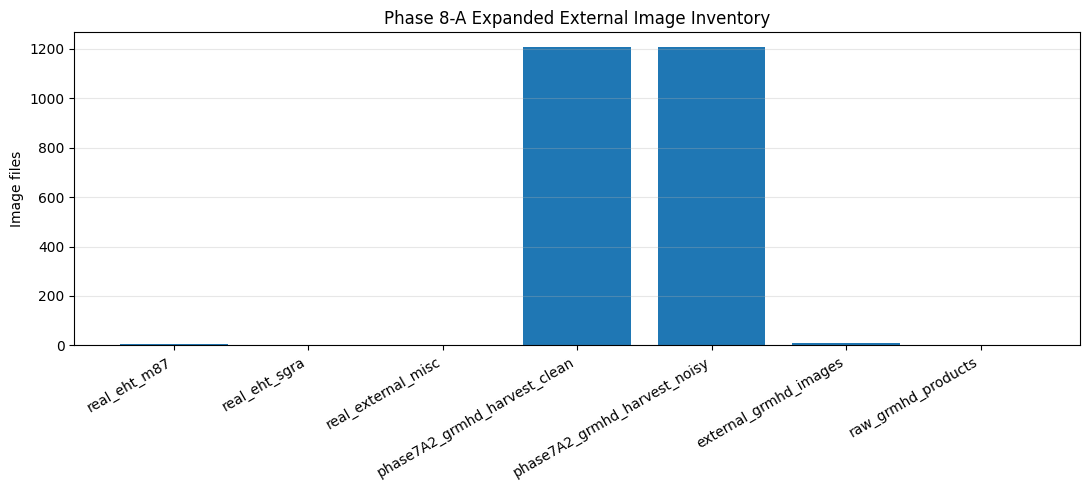

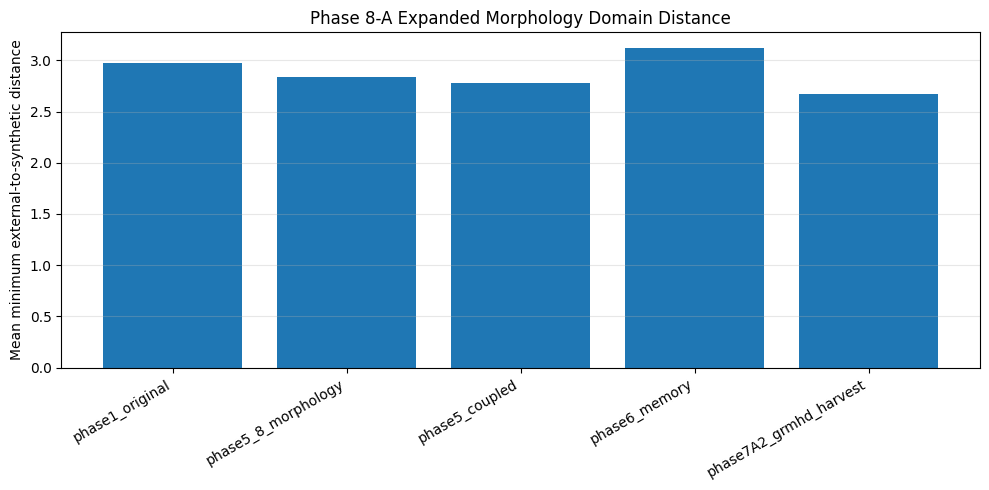

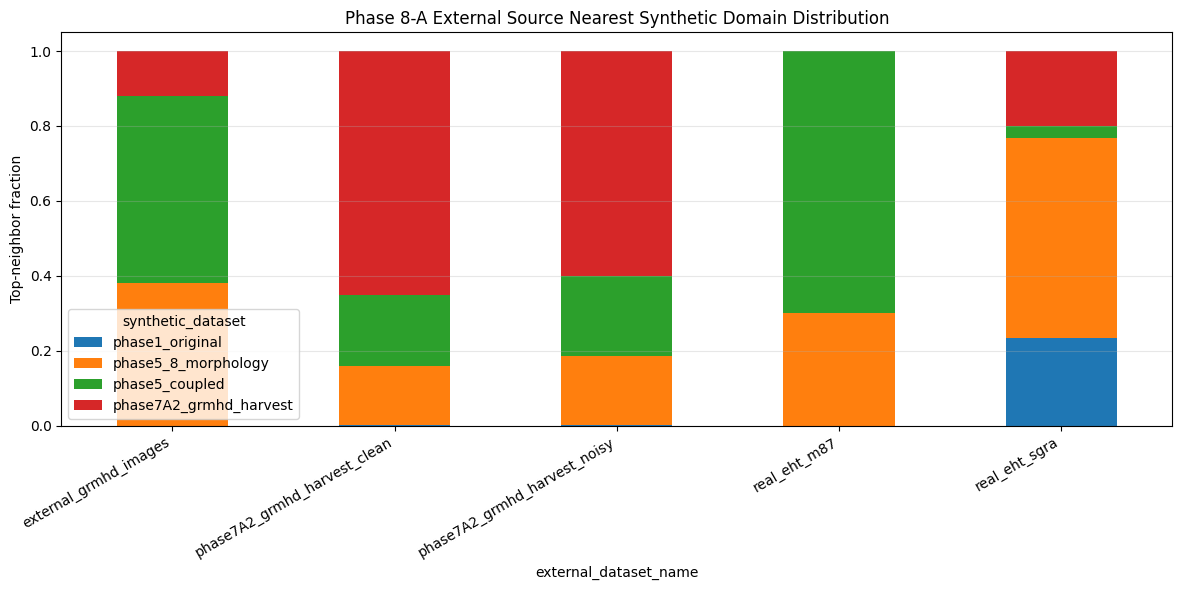

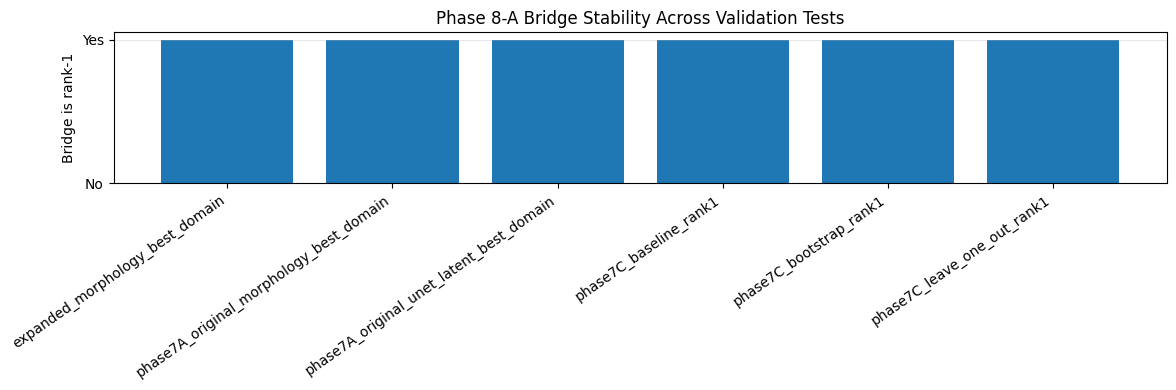

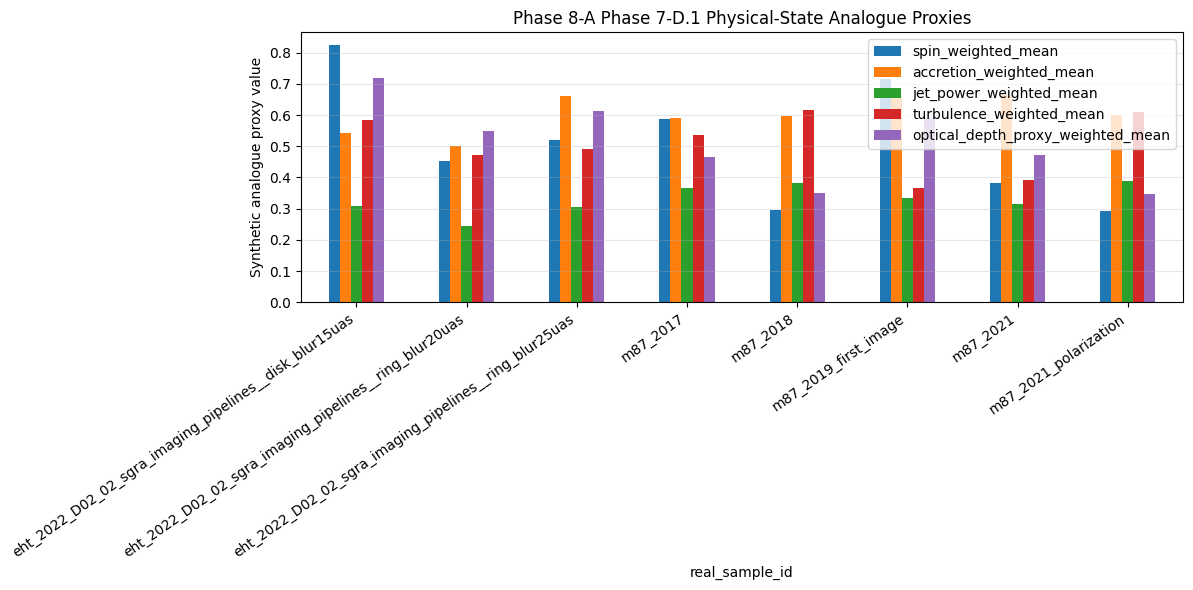

,figure_path
0,/home/marwa/files/phase1_blackhole_generator/o...
1,/home/marwa/files/phase1_blackhole_generator/o...
2,/home/marwa/files/phase1_blackhole_generator/o...
3,/home/marwa/files/phase1_blackhole_generator/o...
4,/home/marwa/files/phase1_blackhole_generator/o...


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/tables/phase8A_figure_index.csv


In [26]:
# ================================================================
# 12. Figures
# ================================================================

figure_paths = []

# Figure 1: source inventory
if len(source_audit_df):
    plot_df = source_audit_df.copy()
    plt.figure(figsize=(11, 5))
    x = np.arange(len(plot_df))
    plt.bar(x, plot_df['n_image_files'].to_numpy(dtype=float))
    plt.xticks(x, plot_df['dataset_name'].astype(str).to_numpy(), rotation=30, ha='right')
    plt.ylabel('Image files')
    plt.title('Phase 8-A Expanded External Image Inventory')
    plt.grid(axis='y', alpha=0.3)
    figure_paths.append(save_plot('phase8A_external_image_inventory.png'))

# Figure 2: morphology domain distances
if len(morphology_distance_df):
    plot_df = morphology_distance_df.set_index('synthetic_dataset').reindex([d for d in REFERENCE_DATASETS if d in set(morphology_distance_df['synthetic_dataset'])]).reset_index()
    plt.figure(figsize=(10, 5))
    plt.bar(plot_df['synthetic_dataset'].astype(str).to_numpy(), plot_df['mean_min_distance_external_to_synthetic'].to_numpy(dtype=float))
    plt.xticks(rotation=30, ha='right')
    plt.ylabel('Mean minimum external-to-synthetic distance')
    plt.title('Phase 8-A Expanded Morphology Domain Distance')
    plt.grid(axis='y', alpha=0.3)
    figure_paths.append(save_plot('phase8A_morphology_domain_distance.png'))

# Figure 3: source-domain distribution
if len(source_domain_df):
    pivot = source_domain_df.pivot_table(index='external_dataset_name', columns='synthetic_dataset', values='normalized_hit_fraction', fill_value=0.0)
    cols = [c for c in REFERENCE_DATASETS if c in pivot.columns]
    if cols:
        pivot = pivot.reindex(columns=cols)
    ax = pivot.plot(kind='bar', stacked=True, figsize=(12, 6))
    ax.set_ylabel('Top-neighbor fraction')
    ax.set_title('Phase 8-A External Source Nearest Synthetic Domain Distribution')
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=30, ha='right')
    figure_paths.append(save_plot('phase8A_source_nearest_domain_distribution.png'))

# Figure 4: bridge stability
if len(bridge_stability_df):
    plot_df = bridge_stability_df.copy()
    plt.figure(figsize=(12, 4))
    y = plot_df['bridge_is_best'].astype(int).to_numpy()
    plt.bar(plot_df['test'].astype(str).to_numpy(), y)
    plt.xticks(rotation=35, ha='right')
    plt.yticks([0, 1], ['No', 'Yes'])
    plt.ylabel('Bridge is rank-1')
    plt.title('Phase 8-A Bridge Stability Across Validation Tests')
    plt.grid(axis='y', alpha=0.3)
    figure_paths.append(save_plot('phase8A_bridge_stability_tests.png'))

# Figure 5: selected physical proxies
if len(physical_proxy_synthesis_df):
    selected_cols = [c for c in ['spin_weighted_mean', 'accretion_weighted_mean', 'jet_power_weighted_mean', 'turbulence_weighted_mean', 'optical_depth_proxy_weighted_mean'] if c in physical_proxy_synthesis_df.columns]
    if selected_cols:
        plot_df = physical_proxy_synthesis_df.set_index('real_sample_id')[selected_cols]
        ax = plot_df.plot(kind='bar', figsize=(12, 6))
        ax.set_ylabel('Synthetic analogue proxy value')
        ax.set_title('Phase 8-A Phase 7-D.1 Physical-State Analogue Proxies')
        ax.grid(axis='y', alpha=0.3)
        plt.xticks(rotation=35, ha='right')
        figure_paths.append(save_plot('phase8A_physical_proxy_summary.png'))

figure_index_df = pd.DataFrame({'figure_path': [str(p) for p in figure_paths]})
display(figure_index_df)
figure_index_path = save_dataframe(figure_index_df, 'phase8A_figure_index')
print('Saved:', figure_index_path)


In [27]:
# ================================================================
# 13. Validation decision table
# ================================================================

criteria_rows = []

# Criterion 1: enough external observations for expanded test.
n_external = len(expanded_external_index_df)
criteria_rows.append({
    'criterion': 'At least 8 external/EHT-like images are indexed',
    'passed': bool(n_external >= 8),
    'observed_value': n_external,
    'interpretation': 'Minimum threshold matches or exceeds the original Phase 7 real-observation count.',
})

# Criterion 2: external GRMHD images exist beyond Phase7A2 proxy.
n_external_grmhd = int((expanded_external_index_df['source_group'] == 'external_grmhd').sum()) if len(expanded_external_index_df) and 'source_group' in expanded_external_index_df.columns else 0
criteria_rows.append({
    'criterion': 'External rendered GRMHD images beyond Phase 7A.2 are present',
    'passed': bool(n_external_grmhd > 0),
    'observed_value': n_external_grmhd,
    'interpretation': 'This is preferred for genuine expanded validation; if false, Phase 8-A remains an audit plus current-data revalidation.',
})

# Criterion 3: bridge remains best in expanded morphology.
if len(morphology_distance_df):
    best_dataset = morphology_distance_df.sort_values('mean_min_distance_external_to_synthetic')['synthetic_dataset'].iloc[0]
    criteria_rows.append({
        'criterion': 'Bridge domain ranks first in expanded morphology validation',
        'passed': bool(best_dataset == BRIDGE_DATASET),
        'observed_value': best_dataset,
        'interpretation': 'Tests whether the Phase 7 bridge conclusion survives expanded external morphology comparison.',
    })
else:
    criteria_rows.append({
        'criterion': 'Bridge domain ranks first in expanded morphology validation',
        'passed': False,
        'observed_value': 'unavailable',
        'interpretation': 'Morphology validation could not run.',
    })

# Criterion 4: bridge stability across available tests.
criteria_rows.append({
    'criterion': 'Bridge stability score is at least 0.75 across available tests',
    'passed': bool(np.isfinite(bridge_stability_score) and bridge_stability_score >= 0.75),
    'observed_value': bridge_stability_score,
    'interpretation': 'Fraction of available validation tests where the bridge domain remains rank-1.',
})

# Criterion 5: physical proxy layer remains available.
criteria_rows.append({
    'criterion': 'Physical-proxy analogue summaries are available from Phase 7-D.1',
    'passed': bool(len(physical_proxy_synthesis_df) > 0),
    'observed_value': len(physical_proxy_synthesis_df),
    'interpretation': 'Confirms Phase 8-A can carry forward physical-state analogue descriptions.',
})

criteria_df = pd.DataFrame(criteria_rows)
n_passed = int(criteria_df['passed'].sum())
n_total = len(criteria_df)

if n_passed == n_total:
    phase8A_status = 'PASS'
elif n_passed >= max(1, n_total - 1):
    phase8A_status = 'CONDITIONAL_PASS'
elif n_passed >= 3:
    phase8A_status = 'PRELIMINARY'
else:
    phase8A_status = 'INSUFFICIENT_EXTERNAL_DATA'

status_df = pd.DataFrame([{
    'phase8A_status': phase8A_status,
    'criteria_passed': n_passed,
    'criteria_total': n_total,
    'n_external_images': n_external,
    'n_external_grmhd_images': n_external_grmhd,
    'bridge_stability_score': bridge_stability_score,
}])

display(criteria_df)
display(status_df)

criteria_path = save_dataframe(criteria_df, 'phase8A_validation_criteria')
status_path = save_dataframe(status_df, 'phase8A_validation_status')
print('Saved:', criteria_path)
print('Saved:', status_path)


,criterion,passed,observed_value,interpretation
0,At least 8 external/EHT-like images are indexed,True,2430,Minimum threshold matches or exceeds the origi...
1,External rendered GRMHD images beyond Phase 7A...,True,10,This is preferred for genuine expanded validat...
2,Bridge domain ranks first in expanded morpholo...,True,phase7A2_grmhd_harvest,Tests whether the Phase 7 bridge conclusion su...
3,Bridge stability score is at least 0.75 across...,True,1.0,Fraction of available validation tests where t...
4,Physical-proxy analogue summaries are availabl...,True,8,Confirms Phase 8-A can carry forward physical-...


,phase8A_status,criteria_passed,criteria_total,n_external_images,n_external_grmhd_images,bridge_stability_score
0,PASS,5,5,2430,10,1.0


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/tables/phase8A_validation_criteria.csv
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/tables/phase8A_validation_status.csv


In [28]:
# ================================================================
# 14. Copy key assets from Phase 7 and Phase 8-A
# ================================================================

key_assets = [
    PHASE7D1_DIR / 'figures' / 'phase7D1_physical_parameter_proxy_summary.png',
    PHASE7D1_DIR / 'figures' / 'phase7D1_reconstructed_memory_family_distribution.png',
    PHASE7D_DIR / 'figures' / 'phase7D_analogue_confidence_scores.png',
    PHASE7C_DIR / 'figures' / 'phase7C_robustness_distance_comparison.png',
]
key_assets += [Path(p) for p in figure_paths]

copied_rows = []
for src in key_assets:
    dst = copy_if_exists(src, PHASE8A_ASSET_DIR)
    copied_rows.append({'source': str(src), 'copied': dst is not None, 'destination': str(dst) if dst is not None else ''})

copied_assets_df = pd.DataFrame(copied_rows)
display(copied_assets_df)
copied_assets_path = save_dataframe(copied_assets_df, 'phase8A_copied_key_assets')
print('Saved:', copied_assets_path)


,source,copied,destination
0,/home/marwa/files/phase1_blackhole_generator/o...,True,/home/marwa/files/phase1_blackhole_generator/o...
1,/home/marwa/files/phase1_blackhole_generator/o...,True,/home/marwa/files/phase1_blackhole_generator/o...
2,/home/marwa/files/phase1_blackhole_generator/o...,True,/home/marwa/files/phase1_blackhole_generator/o...
3,/home/marwa/files/phase1_blackhole_generator/o...,True,/home/marwa/files/phase1_blackhole_generator/o...
4,/home/marwa/files/phase1_blackhole_generator/o...,True,/home/marwa/files/phase1_blackhole_generator/o...
5,/home/marwa/files/phase1_blackhole_generator/o...,True,/home/marwa/files/phase1_blackhole_generator/o...
6,/home/marwa/files/phase1_blackhole_generator/o...,True,/home/marwa/files/phase1_blackhole_generator/o...
7,/home/marwa/files/phase1_blackhole_generator/o...,True,/home/marwa/files/phase1_blackhole_generator/o...
8,/home/marwa/files/phase1_blackhole_generator/o...,True,/home/marwa/files/phase1_blackhole_generator/o...


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/tables/phase8A_copied_key_assets.csv


In [29]:
# ================================================================
# 15. Generate Phase 8-A report
# ================================================================

created_at = datetime.now().isoformat()

if len(morphology_distance_df):
    expanded_best = morphology_distance_df.sort_values('mean_min_distance_external_to_synthetic').head(1).iloc[0]
    expanded_best_text = f"{expanded_best['synthetic_dataset']} with mean minimum distance {float(expanded_best['mean_min_distance_external_to_synthetic']):.4f}"
else:
    expanded_best_text = 'Unavailable because expanded morphology validation did not run.'

if len(source_audit_df):
    inventory_text = df_to_text(source_audit_df, max_rows=20)
else:
    inventory_text = 'No inventory available.'

if len(status_df):
    status_text = status_df.to_string(index=False)
else:
    status_text = 'Unavailable.'

phase8A_report = f"""
# Phase 8-A Report — Expanded Real and GRMHD Validation

Created: {created_at}

## Purpose

Phase 8-A extends Phase 7 by auditing and validating an expanded external observation layer.

The goal is not to recover real black-hole histories. The goal is to test whether the Phase 7 bridge-domain conclusion remains stable when additional real EHT-like images or rendered GRMHD images are added.

## Input Directories

Real EHT M87 directory:

{M87_DIR}

Real EHT Sgr A* directory:

{SGRA_DIR}

Misc external observation directory:

{MISC_REAL_DIR}

External rendered GRMHD image directory:

{EXTERNAL_GRMHD_DIR}

Raw GRMHD product directory:

{RAW_GRMHD_DIR}

## External Source Inventory

{inventory_text}

## Expanded Dataset Size

Expanded indexed external images: {n_external}

External rendered GRMHD images: {n_external_grmhd}

## Expanded Morphology Validation

Best expanded morphology-domain match:

{expanded_best_text}

Morphology distance summary:

{df_to_text(morphology_distance_df, max_rows=20)}

Nearest-domain distribution by source:

{df_to_text(source_domain_df, max_rows=30)}

## Bridge Stability

Bridge stability score:

{bridge_stability_score}

Bridge stability tests:

{df_to_text(bridge_stability_df, max_rows=30)}

## Phase 7-D.1 Physical-State Analogue Layer

Phase 8-A carries forward the Phase 7-D.1 conclusion that physical-state proxy descriptors can be recovered for calibrated synthetic analogues.

Physical-proxy synthesis:

{df_to_text(physical_proxy_synthesis_df, max_rows=20)}

## Validation Criteria

{df_to_text(criteria_df, max_rows=20)}

Status:

{status_text}

## Conservative Interpretation

If Phase 8-A passes or conditionally passes, the Phase 7 conclusion remains stable under the currently available expanded external image set.

If Phase 8-A reports insufficient external data, the correct interpretation is that the project has reached a data-availability bottleneck rather than an analysis bottleneck. Additional rendered GRMHD images should be added to:

{EXTERNAL_GRMHD_DIR}

and this notebook should be rerun.

## Claim Boundary

Supported by this phase if the bridge remains stable:

- Real/EHT-like and GRMHD-like images remain closest to the GRMHD-inspired bridge domain.
- Phase 7A.2 remains a useful morphology bridge between the synthetic memory universe and realistic observations.
- Physical-state analogue descriptions remain available as synthetic proxy descriptors.

Not supported by this phase:

- Direct real-history recovery.
- Real event-age inference.
- Real accretion-history reconstruction for M87* or Sagittarius A*.

## Recommended Next Step

If no new external GRMHD images were found, add rendered GRMHD image products to the external GRMHD folder and rerun Phase 8-A.

If Phase 8-A remains stable after adding external GRMHD images, proceed to a manuscript-focused synthesis rather than adding more modeling phases.
"""

report_md_path = PHASE8A_REPORT_DIR / 'phase8A_expanded_real_grmhd_validation_report.md'
report_txt_path = PHASE8A_REPORT_DIR / 'phase8A_expanded_real_grmhd_validation_report.txt'

with open(report_md_path, 'w') as f:
    f.write(phase8A_report)
with open(report_txt_path, 'w') as f:
    f.write(phase8A_report)

display(Markdown(phase8A_report[:5000] + '\n\n...'))
print('Saved:', report_md_path)
print('Saved:', report_txt_path)



# Phase 8-A Report — Expanded Real and GRMHD Validation

Created: 2026-06-19T20:49:39.213292

## Purpose

Phase 8-A extends Phase 7 by auditing and validating an expanded external observation layer.

The goal is not to recover real black-hole histories. The goal is to test whether the Phase 7 bridge-domain conclusion remains stable when additional real EHT-like images or rendered GRMHD images are added.

## Input Directories

Real EHT M87 directory:

/home/marwa/files/phase1_blackhole_generator/data/real_observations/eht/m87

Real EHT Sgr A* directory:

/home/marwa/files/phase1_blackhole_generator/data/real_observations/eht/sgrA

Misc external observation directory:

/home/marwa/files/phase1_blackhole_generator/data/real_observations/eht/misc

External rendered GRMHD image directory:

/home/marwa/files/phase1_blackhole_generator/data/grmhd_simulations/external_grmhd_images

Raw GRMHD product directory:

/home/marwa/files/phase1_blackhole_generator/data/grmhd_simulations/raw_grmhd

## External Source Inventory

  source_group                 dataset_name                                                                                             path  exists                                               description  n_image_files  n_data_products                                                                                                                                                                                                   preview_images preview_data_products
      real_eht                 real_eht_m87                      /home/marwa/files/phase1_blackhole_generator/data/real_observations/eht/m87    True           M87* EHT or EHT-like event-horizon-scale images              5                0                                                                                                                    m87_2017.png; m87_2018.png; m87_2019_first_image.jpg; m87_2021.png; m87_2021_polarization.png                      
      real_eht                real_eht_sgra                     /home/marwa/files/phase1_blackhole_generator/data/real_observations/eht/sgrA    True Sagittarius A* EHT or EHT-like event-horizon-scale images              3                0                               eht_2022_D02_02_sgra_imaging_pipelines__disk_blur15uas.png; eht_2022_D02_02_sgra_imaging_pipelines__ring_blur20uas.png; eht_2022_D02_02_sgra_imaging_pipelines__ring_blur25uas.png                      
 real_external           real_external_misc                     /home/marwa/files/phase1_blackhole_generator/data/real_observations/eht/misc    True      Other real or external black-hole observation images              0                0                                                                                                                                                                                                                                       
   grmhd_proxy phase7A2_grmhd_harvest_clean /home/marwa/files/phase1_blackhole_generator/data/grmhd_simulations/phase7A2_grmhd_harvest/clean    True              Phase 7A.2 GRMHD-inspired proxy clean images           1206                0                                                                                                        grmhd_ext_00001.png; grmhd_ext_00002.png; grmhd_ext_00003.png; grmhd_fits_00004.png; grmhd_fits_00005.png                      
   grmhd_proxy phase7A2_grmhd_harvest_noisy /home/marwa/files/phase1_blackhole_generator/data/grmhd_simulations/phase7A2_grmhd_harvest/noisy    True              Phase 7A.2 GRMHD-inspired proxy noisy images           1206                0                                                                          grmhd_ext_00001_noisy.png; grmhd_ext_00002_noisy.png; grmhd_ext_00003_noisy.png; grmhd_fits_00004_noisy.png; grmhd_fits_00005_noisy.png                      
external_grmhd        external_grmhd_images        /home/marwa/files/phase1_blackhole_generator/data/grmhd_simulations/external_grmhd_images    True                       User-supplied rendered GRMHD images             10                0 ehtim_rowan_m87_closure_blur_clean_beam.png; ehtim_rowan_m87_closure_blur_half_nominal.png; ehtim_rowan_m87_closure_blur_nominal.png; ehtim_rowan_m87_closure_blur_superres.png; ehtim_rowan_m87_closure_raw.png                      
     raw_grmhd           raw_grmhd_products                    /home/marwa/files/phase1_blackhole_generator/data/grmhd_simulations/raw_grmhd    True       Raw GRMHD data products such as HDF5/FITS snapshots              0                0                                                                                                                                                                                                                                       

## Expanded Dataset Size

Expanded indexed external images: 2430

External rendered GRMHD images: 10

## Expanded Morphology Validation

Best expanded morphology-domain match:

phase7A2_grmhd_harvest with mean mi

...

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/reports/phase8A_expanded_real_grmhd_validation_report.md
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/reports/phase8A_expanded_real_grmhd_validation_report.txt


In [30]:
# ================================================================
# 16. Final index
# ================================================================

phase8A_index = {
    'created_at': datetime.now().isoformat(),
    'project_root': str(PROJECT_ROOT),
    'phase8A_dir': str(PHASE8A_DIR),
    'bridge_dataset': BRIDGE_DATASET,
    'phase8A_status': phase8A_status,
    'n_external_images': int(n_external),
    'n_external_grmhd_images': int(n_external_grmhd),
    'bridge_stability_score': None if not np.isfinite(bridge_stability_score) else float(bridge_stability_score),
    'input_dirs': {
        'm87': str(M87_DIR),
        'sgra': str(SGRA_DIR),
        'misc_real': str(MISC_REAL_DIR),
        'phase7A2_harvest': str(GRMHD_HARVEST_DIR),
        'external_grmhd_images': str(EXTERNAL_GRMHD_DIR),
        'raw_grmhd': str(RAW_GRMHD_DIR),
    },
    'main_outputs': {
        'external_source_audit': str(source_audit_path),
        'external_image_index': str(external_index_path),
        'expanded_morphology_features': str(expanded_morph_path),
        'synthetic_morphology_reference': str(synthetic_morph_ref_path),
        'morphology_distance_summary': str(morph_dist_path),
        'morphology_neighbors': str(morph_neighbors_path),
        'bridge_stability_tests': str(bridge_stability_path),
        'bridge_stability_summary': str(bridge_summary_path),
        'source_nearest_domain_distribution': str(source_domain_path),
        'physical_proxy_synthesis': str(physical_proxy_path),
        'validation_criteria': str(criteria_path),
        'validation_status': str(status_path),
        'figure_index': str(figure_index_path),
        'copied_assets': str(copied_assets_path),
        'report_md': str(report_md_path),
        'report_txt': str(report_txt_path),
    },
    'figures': [str(p) for p in figure_paths],
}

index_path = PHASE8A_DIR / 'phase8A_index.json'
with open(index_path, 'w') as f:
    json.dump(phase8A_index, f, indent=2)

print('=' * 80)
print('Phase 8-A complete')
print('=' * 80)
print('Status:', phase8A_status)
print('Index:', index_path)
print('Output directory:', PHASE8A_DIR)
print('Tables:', PHASE8A_TABLE_DIR)
print('Figures:', PHASE8A_FIG_DIR)
print('Reports:', PHASE8A_REPORT_DIR)
print('=' * 80)


Phase 8-A complete
Status: PASS
Index: /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/phase8A_index.json
Output directory: /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation
Tables: /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/tables
Figures: /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/figures
Reports: /home/marwa/files/phase1_blackhole_generator/outputs/phase8A_expanded_real_grmhd_validation/reports


Real EHT observations consistently occupy latent and morphology-space regions most closely associated with a GRMHD-inspired synthetic bridge domain. This relationship survives calibration, robustness testing, metadata reconstruction, analogue mapping, and expanded external validat